## Lasso, XGBoost e Random Forest

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Carregar dados
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Padronizar dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [4]:
#  1. LASSO 
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y)


lasso_importance = pd.DataFrame({ 'Feature': X.columns,'Lasso': np.abs(lasso.coef_)})

#  2. RANDOM FOREST 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

rf_importance = pd.DataFrame({'Feature': X.columns, 'Random Forest': rf.feature_importances_})

#  3. XGBOOST 
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_scaled, y)

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost': xgb.feature_importances_
})


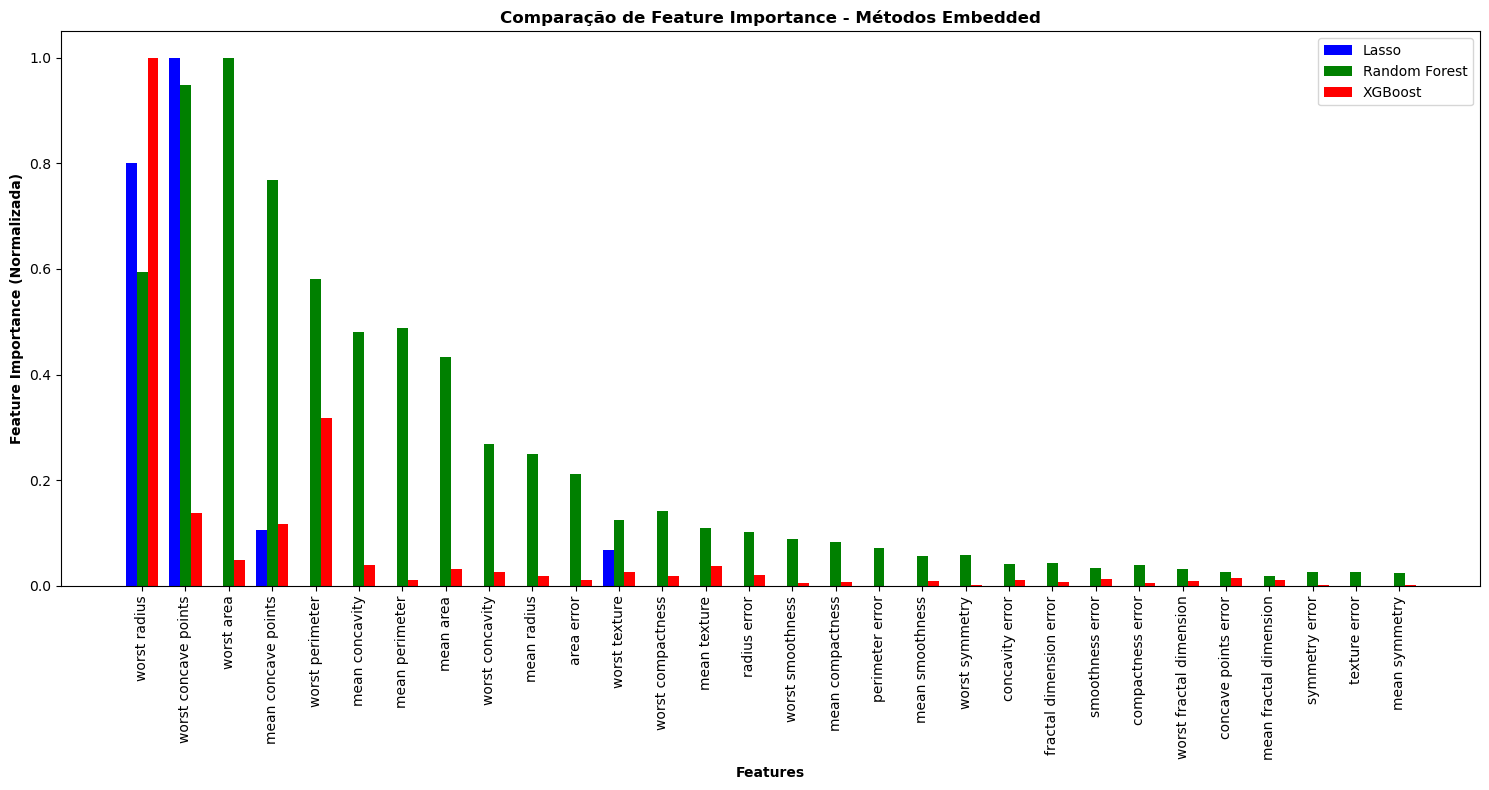

In [5]:
# Merge dos resultados
feature_importance = lasso_importance.merge(rf_importance, on='Feature'
).merge(xgb_importance, on='Feature')

# Normalizar para comparação
feature_importance['Lasso'] = feature_importance['Lasso'] / feature_importance['Lasso'].max()
feature_importance['Random Forest'] = feature_importance['Random Forest'] / feature_importance['Random Forest'].max()
feature_importance['XGBoost'] = feature_importance['XGBoost'] / feature_importance['XGBoost'].max()

# Ordenar por média de importância
feature_importance['Média'] = feature_importance[['Lasso', 'Random Forest', 'XGBoost']].mean(axis=1)
feature_importance = feature_importance.sort_values('Média', ascending=False)

# VISUALIZAÇÃO
plt.figure(figsize=(15, 8))

# Preparar dados para plot
features = feature_importance['Feature']
lasso_values = feature_importance['Lasso']
rf_values = feature_importance['Random Forest']
xgb_values = feature_importance['XGBoost']

# Largura das barras
bar_width = 0.25

# Posições das barras
r1 = np.arange(len(features))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Criar barras
plt.bar(r1, lasso_values, color='blue', width=bar_width, label='Lasso')
plt.bar(r2, rf_values, color='green', width=bar_width, label='Random Forest')
plt.bar(r3, xgb_values, color='red', width=bar_width, label='XGBoost')

# Customização
plt.xlabel('Features', fontweight='bold')
plt.ylabel('Feature Importance (Normalizada)', fontweight='bold')
plt.title('Comparação de Feature Importance - Métodos Embedded', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(features))], features, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()
